This notebook covers the two ways to import a catalog to HATS format: 
- `lsdb.from_dataframe()` for smaller catalogs only (~1-2M rows) which can fit into memory as a single pandas DataFrame
- the `hats-import` pipeline for catalogs that don't fit into memory (more like ~1B rows); the data is read in from a list of files

In addition, the FeatherReader() class was built/tested in this notebook.  This class is fed to the hats-import pipeline in order to read in ATLAS sources from the .feather files that the un-HATS-ed catalog lives in.  See this __[hats-import documentation on File Readers](https://hats-import.readthedocs.io/en/stable/reference/file_readers.html)__ for more information on how to create custom input file readers.  


**You will need:**

- to install the __[hats](https://github.com/astronomy-commons/hats)__, __[hats-import](https://github.com/astronomy-commons/hats-import)__, and __[lsdb](https://github.com/astronomy-commons/lsdb)__ packages and their dependencies 
- the files `select_cat_sample.py` and `hats_import_with_pipeline.py`
- time (minutes for a smaller catalog, hours for a larger catalog)
    - **Note: it is computationally expensive and time-consuming to fully import a catalog to HATS format, but this only needs to be done one time.  Once a catalog is HATS-ed, a user can quickly access it and apply filters/computations to it using the `lsdb` framework.*

**The catalog:**

This notebook is meant to run on Aurora and uses the ATLAS-Refcat2 stellar reference catalog, select columns of which are stored on Aurora in a non-HATS-ed format.  See the readme for a description of the directory structure.

**Selecting a small "toy" catalog to try out these importing methods:**

This notebook reads in ATLAS data from those `.feather` files, and will select a small sample of those sources to demonstrate how an import can be performed.  This is done in two ways:
- If using `lsdb.from_dataframe()`, you can use function `get_rand_cat_sample()` (found in `select_cat_sample.py`) to select a fraction of ATLAS sources from all `.feather` files (evenly distributed across sky) and serve them up in a pandas DataFrame 
- Alternately, if reading data in from files when using the `hats-import` pipeline, you can simply elect to read from a certain number of the `.feather` files (out of the 3072 total) if you're not trying to import the entire ~1B-row catalog 
    - There is a class `FeatherReader()` (found in `hats_import_with_pipeline.py`) that can be provided to the `hats-import` pipeline, allowing it to read in data from `.feather` files

In [ ]:
# Imports
from dask.distributed import Client
import glob
from hats_import.catalog.arguments import ImportArguments
from hats_import.pipeline import pipeline,pipeline_with_client
import healpy as hp
import numpy as np
import os
import pandas as pd
import pyarrow as pa
import sys
import time


# custom functions, etc. by Katie 
from select_cat_sample import get_rand_cat_sample
from hats_import_with_pipeline import import_pipeline, import_pipeline_with_client

# Building the FeatherReader() Class

Read the hats-import docs about File Readers: 
- https://hats-import.readthedocs.io/en/stable/reference/file_readers.html 

Using these files from hats-import and hats:
- https://github.com/astronomy-commons/hats-import/blob/main/src/hats_import/catalog/file_readers/csv.py#L155
- https://github.com/astronomy-commons/hats-import/blob/main/src/hats_import/catalog/file_readers/input_reader.py
- https://github.com/astronomy-commons/hats/blob/main/src/hats/io/file_io/file_io.py#L132


In [1]:
from hats.io import file_io
from hats.io.file_io.file_pointer import get_upath

import pandas as pd
import pyarrow as pa

from pathlib import Path
from upath import UPath

from collections.abc import Generator
from hats_import.catalog.file_readers.input_reader import InputReader

from pyarrow import feather


class FeatherReader(InputReader):
    """Feather reader for the most common Feather reading arguments.
        (This version correctly reads files in chunks)
        Uses pyarrow to read in a feather file chunk-by-chunk.

    Attributes:
        header (int, list of int, None, default 'infer'): rows to
            use as the header with column names
        schema_file (str): path to a parquet schema file. if provided, header names
            and column types will be pulled from the parquet schema metadata.
        column_names (list[str]): the names of columns if no header is available
        type_map (dict): the data types to use for columns
        parquet_kwargs (dict): additional keyword arguments to use when
            reading the parquet schema metadata, passed to pandas.read_parquet.
            See https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html
        kwargs (dict): additional keyword arguments to use when reading
            the feather files with pandas.read_feather.
    """

    def __init__(
        self,
        chunksize=500_000,
        header="infer",
        schema_file=None,
        column_names=None,
        type_map=None,
        parquet_kwargs=None,
        upath_kwargs=None,
        **kwargs,
    ):
        self.chunksize = chunksize
        self.header = header
        self.schema_file = schema_file
        self.column_names = column_names
        self.type_map = type_map
        self.parquet_kwargs = parquet_kwargs
        self.upath_kwargs = upath_kwargs
        self.kwargs = kwargs

        schema_parquet = None
        if self.schema_file:
            if self.parquet_kwargs is None:
                self.parquet_kwargs = {}
            schema_parquet = file_io.read_parquet_file_to_pandas(
                self.schema_file,
                **self.parquet_kwargs,
            )

        if self.column_names:
            self.kwargs["names"] = self.column_names
        elif not self.header and schema_parquet is not None:
            self.kwargs["names"] = list(schema_parquet.columns)

        if self.type_map:
            self.kwargs["dtype"] = self.type_map
        elif schema_parquet is not None:
            self.kwargs["dtype"] = schema_parquet.dtypes.to_dict()

    def read(self, input_file,read_columns=None) -> Generator[pd.DataFrame]:
        input_file = self.regular_file_exists(input_file)
        
        # read feather file in chunks
        reader = pa.ipc.open_file(input_file)
        for i in range(reader.num_record_batches):
            batch = reader.get_batch(i)
            df = batch.to_pandas()
            yield df



class FeatherReader_old(InputReader):
    """Feather reader for the most common Feather reading arguments.
    (this version reads in an entire file and selects chunks; this is not right!!)
    This uses `pandas.read_feather`

    Attributes:
        header (int, list of int, None, default 'infer'): rows to
            use as the header with column names
        schema_file (str): path to a parquet schema file. if provided, header names
            and column types will be pulled from the parquet schema metadata.
        column_names (list[str]): the names of columns if no header is available
        type_map (dict): the data types to use for columns
        parquet_kwargs (dict): additional keyword arguments to use when
            reading the parquet schema metadata, passed to pandas.read_parquet.
            See https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html
        kwargs (dict): additional keyword arguments to use when reading
            the feather files with pandas.read_feather.
    """

    def __init__(
        self,
        chunksize=500_000,
        header="infer",
        schema_file=None,
        column_names=None,
        type_map=None,
        parquet_kwargs=None,
        upath_kwargs=None,
        **kwargs,
    ):
        self.chunksize = chunksize
        self.header = header
        self.schema_file = schema_file
        self.column_names = column_names
        self.type_map = type_map
        self.parquet_kwargs = parquet_kwargs
        self.upath_kwargs = upath_kwargs
        self.kwargs = kwargs

        schema_parquet = None
        if self.schema_file:
            if self.parquet_kwargs is None:
                self.parquet_kwargs = {}
            schema_parquet = file_io.read_parquet_file_to_pandas(
                self.schema_file,
                **self.parquet_kwargs,
            )

        if self.column_names:
            self.kwargs["names"] = self.column_names
        elif not self.header and schema_parquet is not None:
            self.kwargs["names"] = list(schema_parquet.columns)

        if self.type_map:
            self.kwargs["dtype"] = self.type_map
        elif schema_parquet is not None:
            self.kwargs["dtype"] = schema_parquet.dtypes.to_dict()

    def read(self, input_file,read_columns=None) -> Generator[pd.DataFrame]:
        f_file = pd.read_feather(input_file)
        for sub_file in [f_file[i:i+self.chunksize] for i in range(0,f_file.shape[0],self.chunksize)]:
            yield sub_file



## Testing the FeatherReader with a little import:

In [ ]:
fils = glob.glob("/etc/rico/atlas_refcat2/*/*/*",recursive=True)
args = ImportArguments(
    ra_column="ra",
    dec_column="dec",
    input_file_list=fils[:100], #"/etc/rico/atlas_refcat2/0/0/part-0.feather"],
    output_artifact_name="atlas_testy",
    output_path="/net/scratch/kmfas/atlas_refcat2/testy/",
    lowest_healpix_order=2,
    highest_healpix_order=10,
    pixel_threshold=5000,
    file_reader=FeatherReader(),
    )

In [ ]:
with Client(n_workers=4) as client:
    pipeline_with_client(args, client)

In [ ]:
testcat = lsdb.open_catalog("/net/scratch/kmfas/atlas_refcat2/atlas_1000files/")

In [ ]:
fig,ax = testcat.plot_pixels(plot_title="Test (first 1000 files) of ATLAS-Refcat2")

# Importing catalogs to HATS with 2 options:

## (1) lsdb.from_dataframe()

## (2) hats-import pipeline

The `hats_import_with_pipeline.py` script contains the same code/functionality.

In [10]:
# Setup

# catalog name
cat = "atlas" 
cat_name = "ATLAS-Refcat2"

# directory on disk containing un-HATS-ed catalog
cat_inpath = "/etc/rico/atlas_refcat2/"

# Files containing un-HATS-ed catalog, on disk
cat_infiles = "*/*/*.feather" 

# Number of files to read in 
nfiles = 1000 # if you want to read all files (unadvisable!), set to 0

# catalog output path (where  HATS-ed cat will go)
cat_outpath = "/net/scratch/kmfas/atlas_refcat2/" 

# catalog output name (name of HATASed cat)
cat_outname = "atlas_"+str(nfiles)+"files" #args.cat_outname[0]

# Inport arguments (to feed to hats-import pipeline)
lo_hp = 2 # lowest-order HEALPix
hi_hp = 12 # highets-order HEALPix
pix_thrsh = 5000 # max number of sources per HATS pixel/partition 
n_dask_workers = 4 # number of dask workers
n_dask_threads = 1 # number of threads per dask worker
mem_lim = '16GiB'

# Get a list of files containing the un-HATSed catalog
lst = glob.glob(cat_inpath+cat_infiles,recursive=True)
ntot = len(lst)
if nfiles!=0: lst = lst[:nfiles]

Try importing with `hats-import.pipeline()`, which creates a default Dask Client for which you can specify the number of workers and threads (don't actually do this on Aurora, as Dask will allocate total system RAM to its workers):

In [ ]:
# Import the catalog with pipeline
print(f"Importing catalog {cat_name} to HATS format....")
if nfiles!=0: print(f"...only from {nfiles}/{ntot} files in {cat_inpath}")
else: print(f"...from all {ntot} files in {cat_inpath}")
print(f"HATSed catalog will be written to {cat_outpath+cat_outname}")
print("---------------------------------------")
import_pipeline(lst,cat_outpath,cat_outname,FeatherReader(),lo_hp,hi_hp,pix_thrsh,n_dask_workers,n_dask_threads)
print("---------------------------------------")
print("Catalog imported?")

Importing catalog ATLAS-Refcat2 to HATS format....
...only from 100/3072 files in /etc/rico/atlas_refcat2/
HATSed catalog will be written to /net/scratch/kmfas/atlas_refcat2/atlas_100files
---------------------------------------


Catalog: Planning  :   0%|          | 0/4 [00:00<?, ?it/s]

Catalog: Mapping   :   0%|          | 0/100 [00:00<?, ?it/s]

Catalog: Binning   :   0%|          | 0/2 [00:00<?, ?it/s]

Catalog: Splitting :   0%|          | 0/100 [00:00<?, ?it/s]

Catalog: Reducing  :   0%|          | 0/4936 [00:00<?, ?it/s]

Catalog: Finishing :   0%|          | 0/6 [00:00<?, ?it/s]

---------------------------------------
Catalog imported?


Now try importing with `hats-import.pipeline_with_client`, which allows you to create and provide a custom Dask Client for which you can define the number of workers and threads *and* the memory limit per worker (the Right Way):

2026-05-18 16:53:32,261 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:46389' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'map_to_pixels-3632565c931a3e7c6454c63a8b17e33b', 'map_to_pixels-e993f67076e3f7707243d6e770b65dbd', 'map_to_pixels-ccb870f1601f58e265921b70fe9c3516', 'map_to_pixels-03ce248ba58f80c24ee6403aea8d8083', 'map_to_pixels-dce3e424bf21f4bb63639de4b22e89e3', 'map_to_pixels-e148738028c99227a1bdd2528bf9acbc', 'map_to_pixels-5878290dd8a4a1cc676350c6ede33f2e', 'map_to_pixels-e6f63abdfb7350cec945179a5ef5a3e0', 'map_to_pixels-b25bb087bb7631722e5406a6791e3842', 'map_to_pixels-e667bdd255048955918332d520c37093', 'map_to_pixels-9d4379a38a923a9811bf14d564c47280', 'map_to_pixels-3d27a08dad4b913fef6a888a74ae8970', 'map_to_pixels-273ffd551fe4b68d21af7cee17c9bafb', 'map_to_pixels-bbff63624035cdb4c5a1886b8dd32941', 'map_to_pixels-838507814168538b077d0ebe402159a4', 'map_to_pixels-94c711128c0a906a8ce79e0bc742d20a', 'map_to_pi

In [9]:
# Import the catalog with pipeline_with_client
print(f"Importing catalog {cat_name} to HATS format....")
if nfiles!=0: print(f"...only from {nfiles}/{ntot} files in {cat_inpath}")
else: print(f"...from all {ntot} files in {cat_inpath}")
print(f"HATSed catalog will be written to {cat_outpath+cat_outname}")
print("---------------------------------------")

# if you don't want a persistent Client:
with Client(n_workers=n_dask_workers,memory_limit=mem_lim,threads_per_worker=n_dask_threads) as client:
        import_pipeline_with_client(client,lst,cat_outpath,cat_outname,FeatherReader(),lo_hp,hi_hp,pix_thrsh)

# if you do want a persistent Client:
#client = Client(n_workers=4,memory_limit="16GiB",threads_per_worker=1)
#import_pipeline_with_client(client,lst,cat_outpath,cat_outname,FeatherReader(),lo_hp,hi_hp,pix_thrsh)
#client.close() remember to close the client before defining another one

print("---------------------------------------")
print("Catalog imported?")


Importing catalog ATLAS-Refcat2 to HATS format....
...only from 500/3072 files in /etc/rico/atlas_refcat2/
HATSed catalog will be written to /net/scratch/kmfas/atlas_refcat2/atlas_500files
---------------------------------------


Catalog: Planning  :   0%|          | 0/4 [00:00<?, ?it/s]

Catalog: Mapping   :   0%|          | 0/500 [00:00<?, ?it/s]

Catalog: Binning   :   0%|          | 0/2 [00:00<?, ?it/s]

Catalog: Splitting :   0%|          | 0/500 [00:00<?, ?it/s]

Catalog: Reducing  :   0%|          | 0/74768 [00:00<?, ?it/s]

Catalog: Finishing :   0%|          | 0/6 [00:00<?, ?it/s]

---------------------------------------
Catalog imported?


In [11]:
# Import the catalog with pipeline_with_client
print(f"Importing catalog {cat_name} to HATS format....")
if nfiles!=0: print(f"...only from {nfiles}/{ntot} files in {cat_inpath}")
else: print(f"...from all {ntot} files in {cat_inpath}")
print(f"HATSed catalog will be written to {cat_outpath+cat_outname}")
print("---------------------------------------")

# if you don't want a persistent Client:
with Client(n_workers=n_dask_workers,memory_limit=mem_lim,threads_per_worker=n_dask_threads) as client:
        import_pipeline_with_client(client,lst,cat_outpath,cat_outname,FeatherReader(),lo_hp,hi_hp,pix_thrsh)

# if you do want a persistent Client:
#client = Client(n_workers=4,memory_limit="16GiB",threads_per_worker=1)
#import_pipeline_with_client(client,lst,cat_outpath,cat_outname,FeatherReader(),lo_hp,hi_hp,pix_thrsh)
#client.close() remember to close the client before defining another one

print("---------------------------------------")
print("Catalog imported?")


Importing catalog ATLAS-Refcat2 to HATS format....
...only from 1000/3072 files in /etc/rico/atlas_refcat2/
HATSed catalog will be written to /net/scratch/kmfas/atlas_refcat2/atlas_1000files
---------------------------------------


Catalog: Planning  :   0%|          | 0/4 [00:00<?, ?it/s]

tmp_path (/net/scratch/kmfas/atlas_refcat2/atlas_1000files/intermediate) contains intermediate files; resuming prior progress.


Catalog: Mapping   :   0%|          | 0/223 [00:00<?, ?it/s]

Catalog: Binning   :   0%|          | 0/2 [00:00<?, ?it/s]

Catalog: Splitting :   0%|          | 0/1000 [00:00<?, ?it/s]

Catalog: Reducing  :   0%|          | 0/190288 [00:00<?, ?it/s]

Catalog: Finishing :   0%|          | 0/6 [00:00<?, ?it/s]

---------------------------------------
Catalog imported?


660.6588001251221


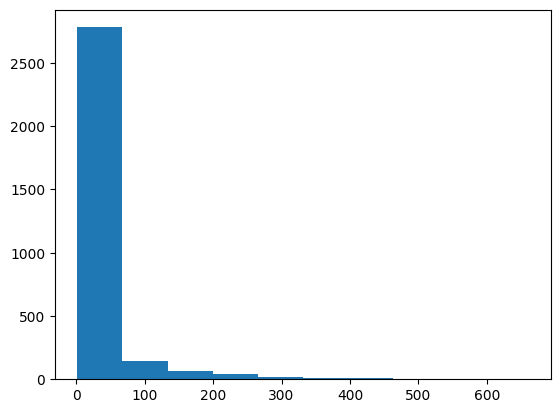

In [15]:
# Get sizes of feather files that the un-HATS-ed ATLAS is stored i:
import glob
import os
import matplotlib.pyplot as plt

unhatsed_atlas_files = glob.glob("/etc/rico/atlas_refcat2/*/*/*.feather",recursive=True)
sizes = []
for fl in unhatsed_atlas_files:
    sizes.append(os.path.getsize(fl)/1024/1024)
print(max(sizes))

plt.hist(sizes)
plt.show()

In [12]:
#Estimate pixel threshold
import pyarrow.parquet as pq
import os

ideal_file_size_small = 300 * 1024 * 1024 #300MB
ideal_file_size_large = 1024 * 1024 * 1024 #1GB

sample_parquet_file = '/net/scratch/kmfas/atlas_refcat2/atlas_0_01/dataset/Norder=4/Dir=0/Npix=3057.parquet'
pfile = pq.ParquetFile(sample_parquet_file)
fsize = os.path.getsize(sample_parquet_file)

# estimate of number of rows in a small/large ideal file:
nrows_small_ideal = ideal_file_size_small/fsize*pfile.metadata.num_rows
nrows_large_ideal = ideal_file_size_large/fsize*pfile.metadata.num_rows

print(nrows_large_ideal,nrows_small_ideal)

18851059.361606523 5522771.297345661
